Exploratory analysis of Rhodes et al. (2013) methane data from the NEEM core. Test the following:
1. Is the power spectrum sensitive to the gaps in the data?
2. Can we use MTM or do we need to use Lomb-Scargle?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from hydra import initialize, compose
from pathlib import Path
from astropy.timeseries import LombScargle

In [15]:
## load the data
with initialize(version_base=None, config_path="../configs"):  # configs with data paths
    cfg = compose(config_name="config")
project_root = Path(cfg.paths.project_root)
data_dir = project_root / cfg.paths.observations_cultivated

file_path = data_dir / "rhodesandbrook2019.tab"
with open(file_path) as f:  # remove header rows
    for idx, line in enumerate(f):
        if line.startswith("Depth ice/snow"):
            header_row = idx
            break

df = pd.read_csv(
    file_path,
    sep="\t",
    skiprows=header_row,  # skip everything before the header
    header=0,
)

neem_with_both_ages = df.rename(
    columns={
        "Age [a AD/CE] (Gas age (yr CE) (constant del...)": "gas_age_constant_delta",
        "Age [a AD/CE] (Gas age (yr CE) (variable del...)": "gas_age_variable_delta",
        "CH4 [ppbv] (outliers removed, see abstract)": "ch4",
    }
)
neem_with_both_ages = neem_with_both_ages[
    ["gas_age_constant_delta", "gas_age_variable_delta", "ch4"]
]

In [35]:
## define parameters for plotting
plot_kwargs = {
    "marker": "o",
    "markersize": 0.5,
    "linestyle": "None",
}
tick_periods = [500, 200, 100, 50, 20, 10]


def set_power_spectrum_plot_params(ax, tick_periods=tick_periods):
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.invert_xaxis()
    ax.set_xlabel("Period (years)")
    ax.set_ylabel("Power Spectral Density (ppb$^2$ year)")

    ax.set_xticks(tick_periods)
    ax.set_xticklabels(tick_periods)

<>:8: SyntaxWarning: invalid escape sequence '\D'
<>:14: SyntaxWarning: invalid escape sequence '\D'
<>:8: SyntaxWarning: invalid escape sequence '\D'
<>:14: SyntaxWarning: invalid escape sequence '\D'
/var/folders/sv/shxzb74j0557hzfx0_s5_n4r0000gn/T/ipykernel_50287/2033801938.py:8: SyntaxWarning: invalid escape sequence '\D'
  label="Gas Age (Constant $\Delta$)",
/var/folders/sv/shxzb74j0557hzfx0_s5_n4r0000gn/T/ipykernel_50287/2033801938.py:14: SyntaxWarning: invalid escape sequence '\D'
  label="Gas Age (Variable $\Delta$)",


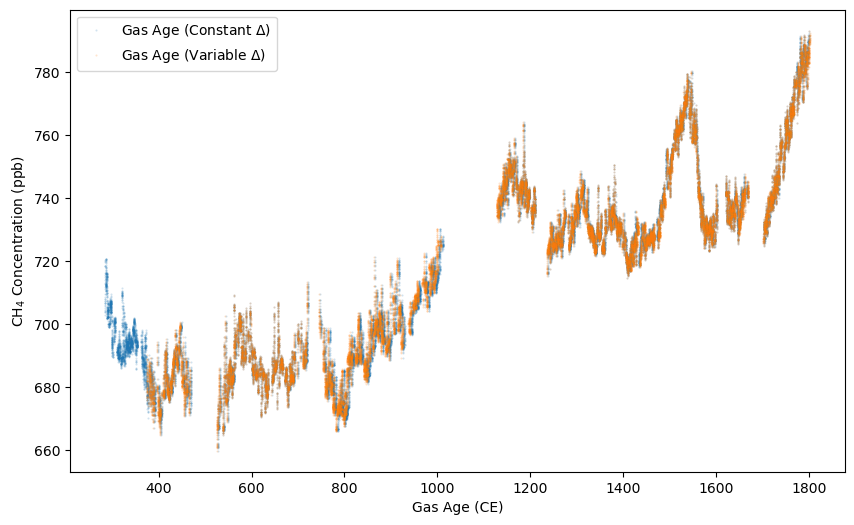

In [27]:
## plot data with both ages
fig, ax = plt.subplots(figsize=(10, 6))
# mask data after 1800 in the constant delta column
mask_constant_delta = neem_with_both_ages["gas_age_constant_delta"] <= 1800

ax.plot(
    neem_with_both_ages["gas_age_constant_delta"][mask_constant_delta],
    neem_with_both_ages["ch4"][mask_constant_delta],
    label="Gas Age (Constant $\Delta$)",
    color="tab:blue",
    alpha=0.2,
    **plot_kwargs,
)
ax.plot(
    neem_with_both_ages["gas_age_variable_delta"][mask_constant_delta],
    neem_with_both_ages["ch4"][mask_constant_delta],
    label="Gas Age (Variable $\Delta$)",
    color="tab:orange",
    alpha=0.2,
    **plot_kwargs,
)
ax.set_xlabel("Gas Age (CE)")
ax.set_ylabel("CH$_4$ Concentration (ppb)")
ax.legend()

Gas age with constant vs variable delta are basically identical, but the constant delta has more data. We'll use the constant delta data. By eye, I think the gaps in the data + the noise in the data are going to make it difficult to use MTM, so we'll use Lomb-Scargle. Even with Lomb-Scargle, the noise may be a problem.

In [ ]:
# "finalize" neem dataset with data before 1800 + constant delta gas age
neem = (
    neem_with_both_ages[mask_constant_delta]
    .copy()
    .drop(columns=["gas_age_variable_delta"])
)
neem = neem.rename(columns={"gas_age_constant_delta": "gas_age"})
mask = neem["gas_age"] <= 1800
neem = neem[mask]

assert neem["gas_age"].is_monotonic_decreasing, "Gas age is not in descending order!"

# calculate and analyze the power spectrum of the NEEM methane data

In [34]:
frequency, power = LombScargle(neem["gas_age"], neem["ch4"]).autopower(
    normalization="psd",
    samples_per_peak=1,
)

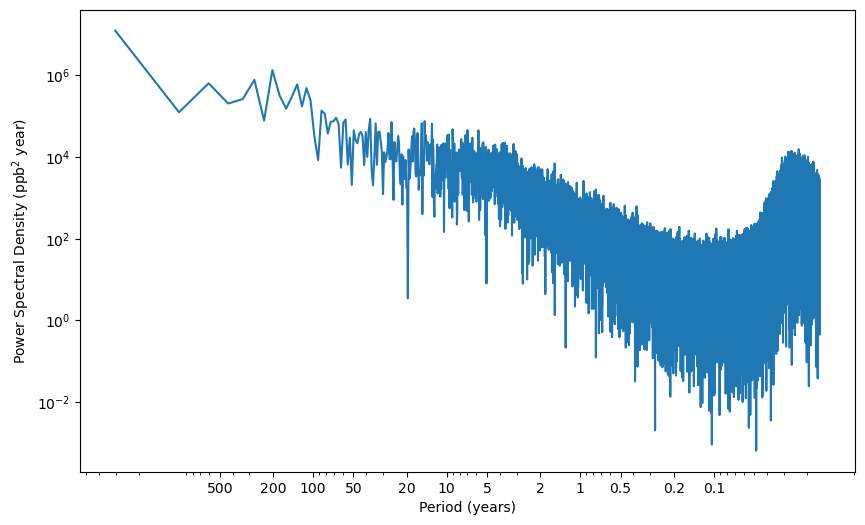

In [38]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(1 / frequency, power)
set_power_spectrum_plot_params(
    ax, tick_periods=[500, 200, 100, 50, 20, 10, 5, 2, 1, 0.5, 0.2, 0.1]
)

Slope: 1.44


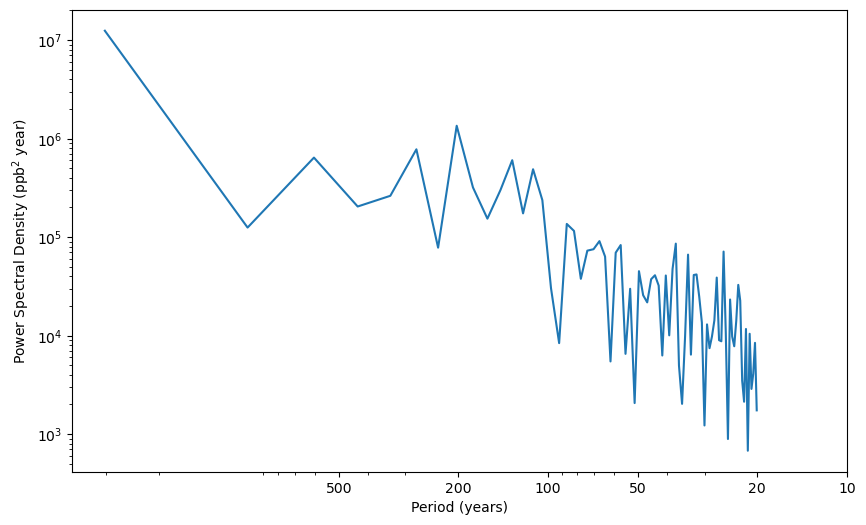

In [43]:
# like the mitchell data, mask the power spectrum to show periods longer than 20 years
fig, ax = plt.subplots(figsize=(10, 6))
mask = 1 / frequency > 20
ax.plot(1 / frequency[mask], power[mask])
set_power_spectrum_plot_params(ax)

# calculate the slope of the power spectrum
from scipy.stats import linregress

log_frequency = np.log10(1 / frequency[mask])
log_power = np.log10(power[mask])
slope, intercept, r_value, p_value, std_err = linregress(log_frequency, log_power)
print(f"Slope: {slope:.2f}")